# Análisis Exploratorio y Estadística Descriptiva
## Inserción Laboral de Migrantes en Chile
**Objetivo:** Caracterizar comparativamente a la población migrante y chilena en dimensiones laborales,
educativas y socioeconómicas mediante estadística descriptiva y visualizaciones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE = os.path.abspath(os.path.join('..', '..')) if 'os' in dir() else __import__('os').path.abspath(__import__('os').path.join('..', '..'))
import os
BASE = os.path.abspath(os.path.join('..', '..'))
DATA = os.path.join(BASE, 'output', 'data')
FIG  = os.path.join(BASE, 'output', 'fig')
os.makedirs(FIG, exist_ok=True)

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
COLORES = {'Chilenos': '#0033A0', 'Migrantes': '#fbcb05'}
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

print("Rutas configuradas.")

Rutas configuradas.


In [2]:
# Cargar datasets procesados
ene = pd.read_parquet(os.path.join(DATA, 'ene_procesada.parquet'))
cas = pd.read_parquet(os.path.join(DATA, 'casen_procesada.parquet'))

print(f"ENE procesada: {ene.shape}")
print(f"CASEN procesada: {cas.shape}")

# Etiquetas legibles
ene['grupo'] = ene['migrante'].map({0: 'Chilenos', 1: 'Migrantes'})
cas['grupo'] = cas['migrante'].map({0: 'Chilenos', 1: 'Migrantes'})

ENE procesada: (325188, 34)
CASEN procesada: (180998, 40)


## 1. Caracterización sociodemográfica

In [3]:
# --- Tabla resumen general ENE ---
print("=== ENE: ESTADÍSTICAS GENERALES POR CONDICIÓN MIGRATORIA ===")
resumen_ene = ene.groupby('grupo').agg(
    n_total=('activ', 'count'),
    edad_media=('edad', 'mean'),
    pct_hombres=('sexo', lambda x: (x==1).mean()),
    pct_ocupado=('ocupado', 'mean'),
    pct_desocupado=('desocupado', 'mean'),
    pct_formal=('formal', 'mean'),
    horas_habituales=('horas_habituales', 'median'),
).round(3)
print(resumen_ene.to_string())

=== ENE: ESTADÍSTICAS GENERALES POR CONDICIÓN MIGRATORIA ===
           n_total  edad_media  pct_hombres  pct_ocupado  pct_desocupado  pct_formal  horas_habituales
grupo                                                                                                 
Chilenos    310798      47.545        0.468        0.508           0.046       0.698              44.0
Migrantes    14390      37.604        0.450        0.715           0.055       0.637              45.0


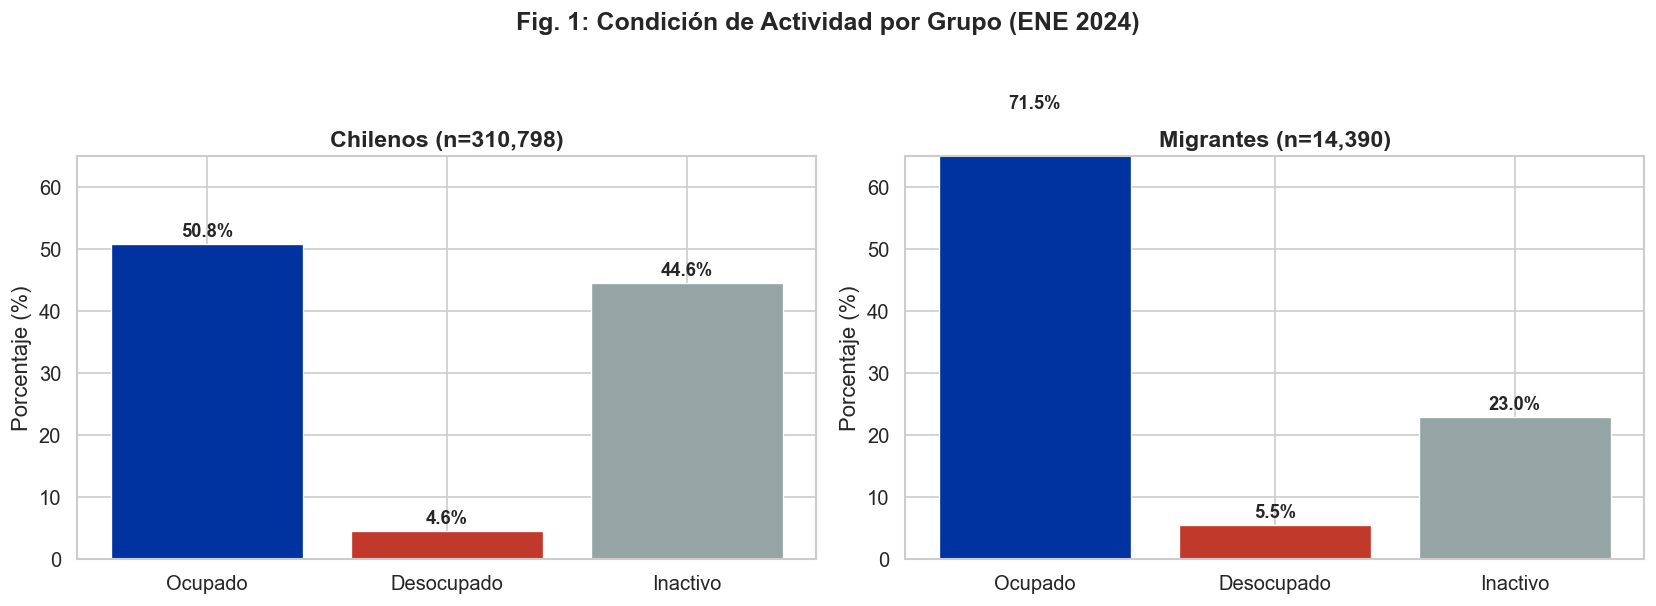

In [4]:
# Figura 1: Pirámide de condición de actividad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (grupo, gdf) in zip(axes, ene.groupby('grupo')):
    activ_counts = gdf['activ'].value_counts().sort_index()
    labels = {1: 'Ocupado', 2: 'Desocupado', 3: 'Inactivo'}
    colores = ['#0033A0', '#c0392b', '#95a5a6']
    bars = ax.bar([labels[k] for k in activ_counts.index],
                  activ_counts.values / len(gdf) * 100,
                  color=colores[:len(activ_counts)], edgecolor='white', linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(f"{grupo} (n={len(gdf):,})", fontsize=14, fontweight='bold')
    ax.set_ylabel("Porcentaje (%)")
    ax.set_ylim(0, 65)
    ax.tick_params(axis='x', rotation=0)

fig.suptitle("Fig. 1: Condición de Actividad por Grupo (ENE 2024)", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig01_actividad_grupo.png'))
plt.show()

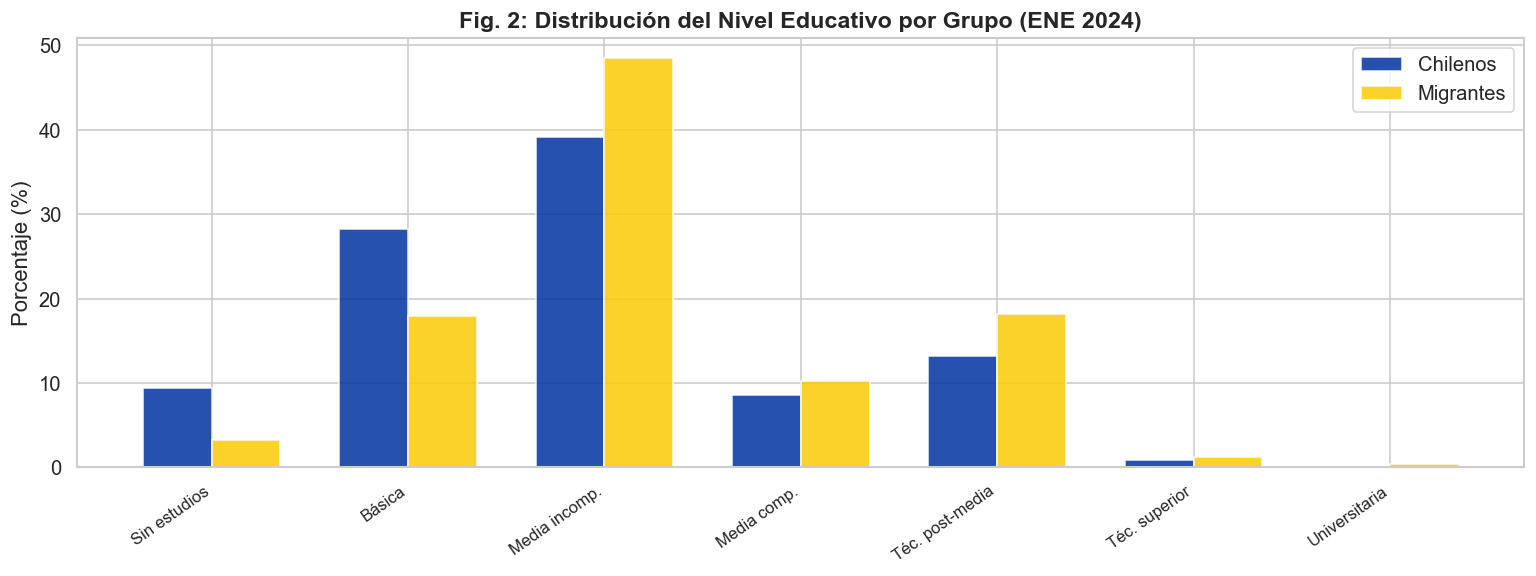

In [5]:
# Figura 2: Distribución educativa comparada
fig, ax = plt.subplots(figsize=(13, 5))

edu_order = ['Sin estudios','Básica','Media incomp.','Media comp.','Téc. post-media','Téc. superior','Universitaria']
edu_data = ene.groupby(['grupo','edu_nivel']).size().unstack(fill_value=0)
# Normalizar
edu_pct = edu_data.div(edu_data.sum(axis=1), axis=0) * 100
edu_pct_plot = edu_pct.reindex(columns=[c for c in edu_order if c in edu_pct.columns])

x = np.arange(len(edu_pct_plot.columns))
width = 0.35
for i, (grupo, row) in enumerate(edu_pct_plot.iterrows()):
    ax.bar(x + i*width - width/2, row.values, width=width,
           label=grupo, color=list(COLORES.values())[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(edu_pct_plot.columns, rotation=35, ha='right', fontsize=10)
ax.set_ylabel("Porcentaje (%)")
ax.set_title("Fig. 2: Distribución del Nivel Educativo por Grupo (ENE 2024)", fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig02_distribucion_educativa.png'))
plt.show()

## 2. Tasas de ocupación y desocupación

=== TASA DE OCUPACIÓN POR SEXO Y GRUPO (ENE) ===
sexo_str   Hombre  Mujer
grupo                   
Chilenos     60.6   42.3
Migrantes    81.2   63.6



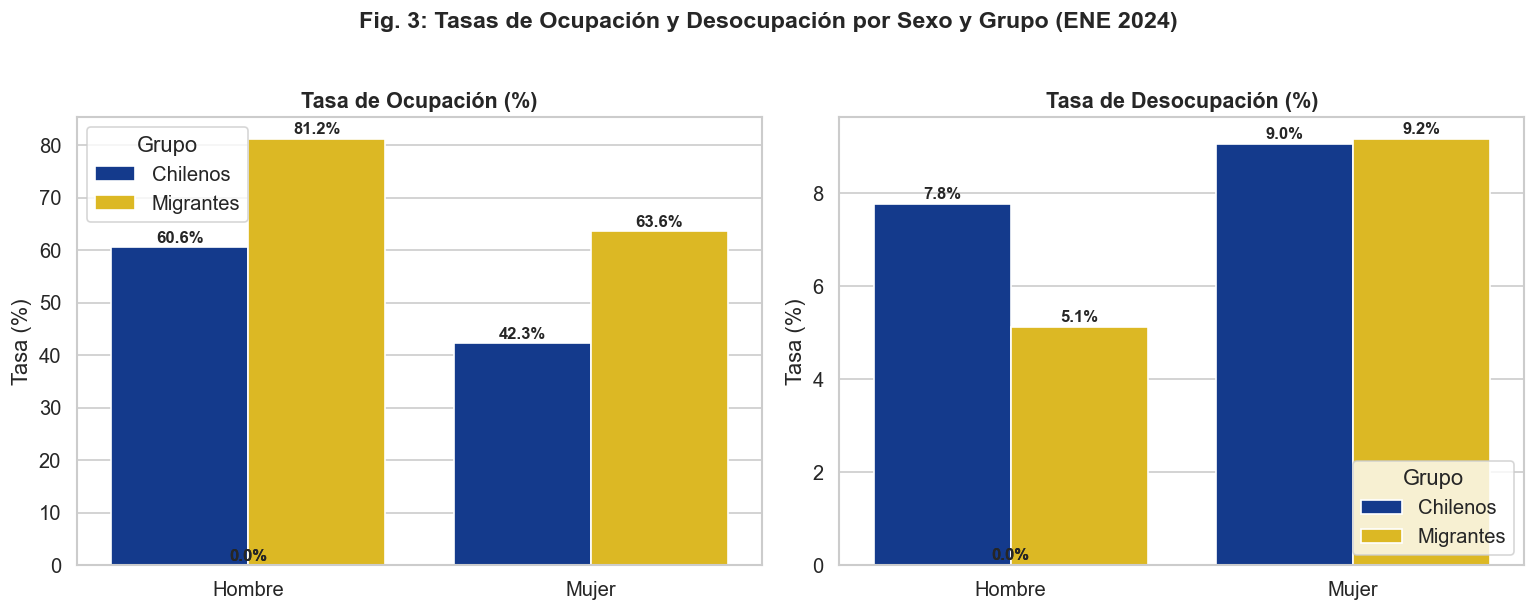

In [6]:
# Tasas por sexo y condición migratoria (ENE)
print("=== TASA DE OCUPACIÓN POR SEXO Y GRUPO (ENE) ===")
tasa_ocup = ene.groupby(['grupo','sexo_str'])['ocupado'].mean().unstack() * 100
print(tasa_ocup.round(1).to_string())
print()

# Figura 3
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tasa ocupación
tasa_ocup_plot = ene.groupby(['grupo','sexo_str'])['ocupado'].mean().reset_index()
tasa_ocup_plot['tasa'] = tasa_ocup_plot['ocupado'] * 100
sns.barplot(data=tasa_ocup_plot, x='sexo_str', y='tasa', hue='grupo',
            palette=COLORES, ax=axes[0], edgecolor='white')
axes[0].set_title("Tasa de Ocupación (%)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Tasa (%)")
axes[0].legend(title='Grupo')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Tasa desocupación
tasa_desoc = ene[ene['activ'].isin([1,2])].groupby(['grupo','sexo_str'])['desocupado'].mean().reset_index()
tasa_desoc['tasa'] = tasa_desoc['desocupado'] * 100
sns.barplot(data=tasa_desoc, x='sexo_str', y='tasa', hue='grupo',
            palette=COLORES, ax=axes[1], edgecolor='white')
axes[1].set_title("Tasa de Desocupación (%)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("Tasa (%)")
axes[1].legend(title='Grupo')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.05),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle("Fig. 3: Tasas de Ocupación y Desocupación por Sexo y Grupo (ENE 2024)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig03_tasas_ocup_desoc.png'))
plt.show()

## 3. Formalidad laboral

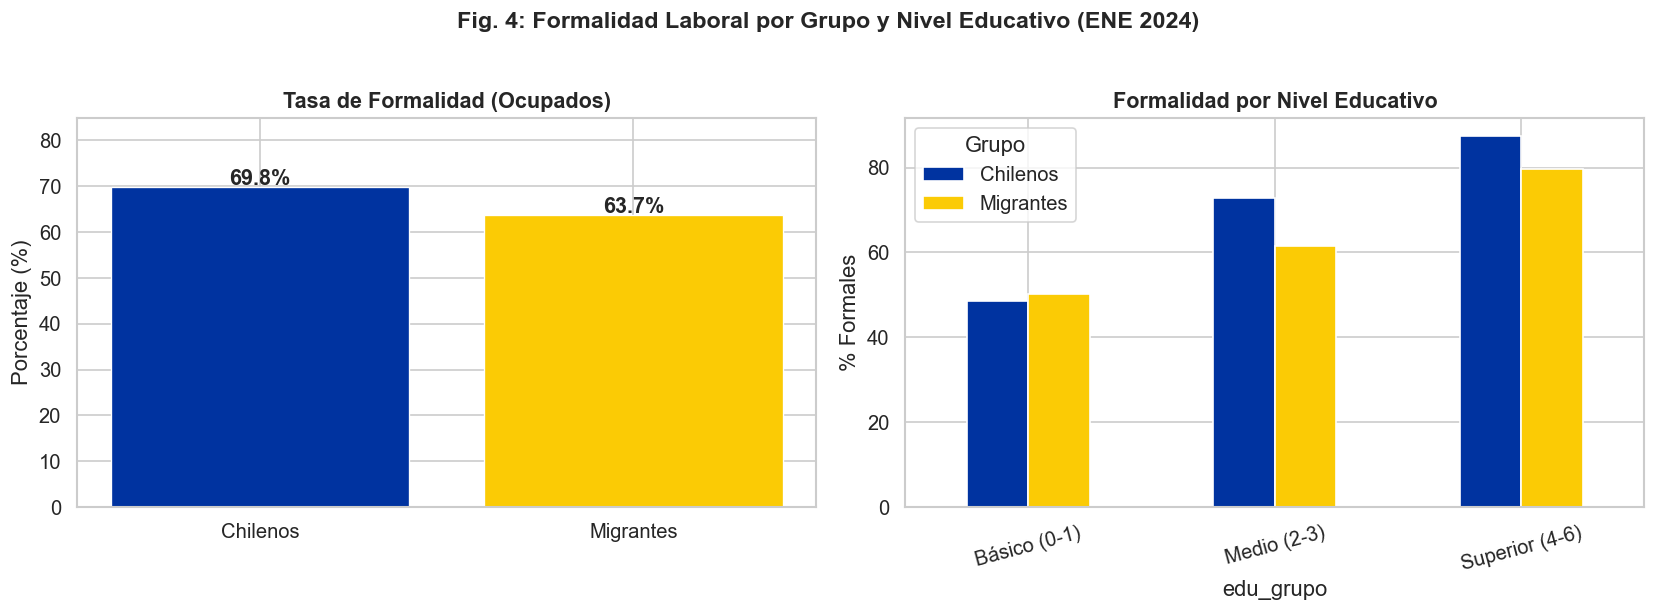

In [7]:
# Figura 4: Formalidad por grupo y nivel educativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: tasa formalidad por grupo
ocup_ene = ene[ene['activ']==1].copy()
form_grupo = ocup_ene.groupby('grupo')['formal'].mean().reset_index()
form_grupo['pct'] = form_grupo['formal'] * 100
bars = axes[0].bar(form_grupo['grupo'], form_grupo['pct'],
                   color=[COLORES[g] for g in form_grupo['grupo']],
                   edgecolor='white', linewidth=0.8)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%", ha='center', fontweight='bold', fontsize=13)
axes[0].set_title("Tasa de Formalidad (Ocupados)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Porcentaje (%)")
axes[0].set_ylim(0, 85)

# Panel derecho: formalidad por grupo educativo
form_edu = ocup_ene.groupby(['grupo','edu_grupo'])['formal'].mean().unstack() * 100
form_edu.T.plot(kind='bar', color=list(COLORES.values()), ax=axes[1],
               edgecolor='white', rot=0)
axes[1].set_title("Formalidad por Nivel Educativo", fontsize=13, fontweight='bold')
axes[1].set_ylabel("% Formales")
axes[1].legend(title='Grupo')
axes[1].tick_params(axis='x', rotation=15)

fig.suptitle("Fig. 4: Formalidad Laboral por Grupo y Nivel Educativo (ENE 2024)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig04_formalidad.png'))
plt.show()

## 4. Ingresos laborales (CASEN)

In [8]:
# Solo ocupados con ingreso registrado
cas_ocup = cas[(cas['activ']==1) & (cas['ingreso_hora'].notna())].copy()
print(f"Ocupados CASEN con ingreso por hora: {len(cas_ocup):,}")

# Tabla ingreso por hora por grupo
ing_tabla = cas_ocup.groupby('grupo')['ingreso_hora'].agg(
    ['mean','median','std',
     lambda x: x.quantile(0.25),
     lambda x: x.quantile(0.75)]
).round(0)
ing_tabla.columns = ['Media','Mediana','Desv_std','P25','P75']
print()
print("=== INGRESO POR HORA (CLP) POR GRUPO ===")
print(ing_tabla.to_string())
print()
brecha_median = (ing_tabla.loc['Migrantes','Mediana'] / ing_tabla.loc['Chilenos','Mediana'] - 1) * 100
print(f"Brecha mediana de ingreso/hora: {brecha_median:.1f}% (migrantes vs chilenos)")

Ocupados CASEN con ingreso por hora: 91,180

=== INGRESO POR HORA (CLP) POR GRUPO ===
            Media  Mediana  Desv_std     P25     P75
grupo                                               
Chilenos   4240.0   3149.0    3325.0  2519.0  4811.0
Migrantes  3663.0   2887.0    2826.0  2406.0  3849.0

Brecha mediana de ingreso/hora: -8.3% (migrantes vs chilenos)


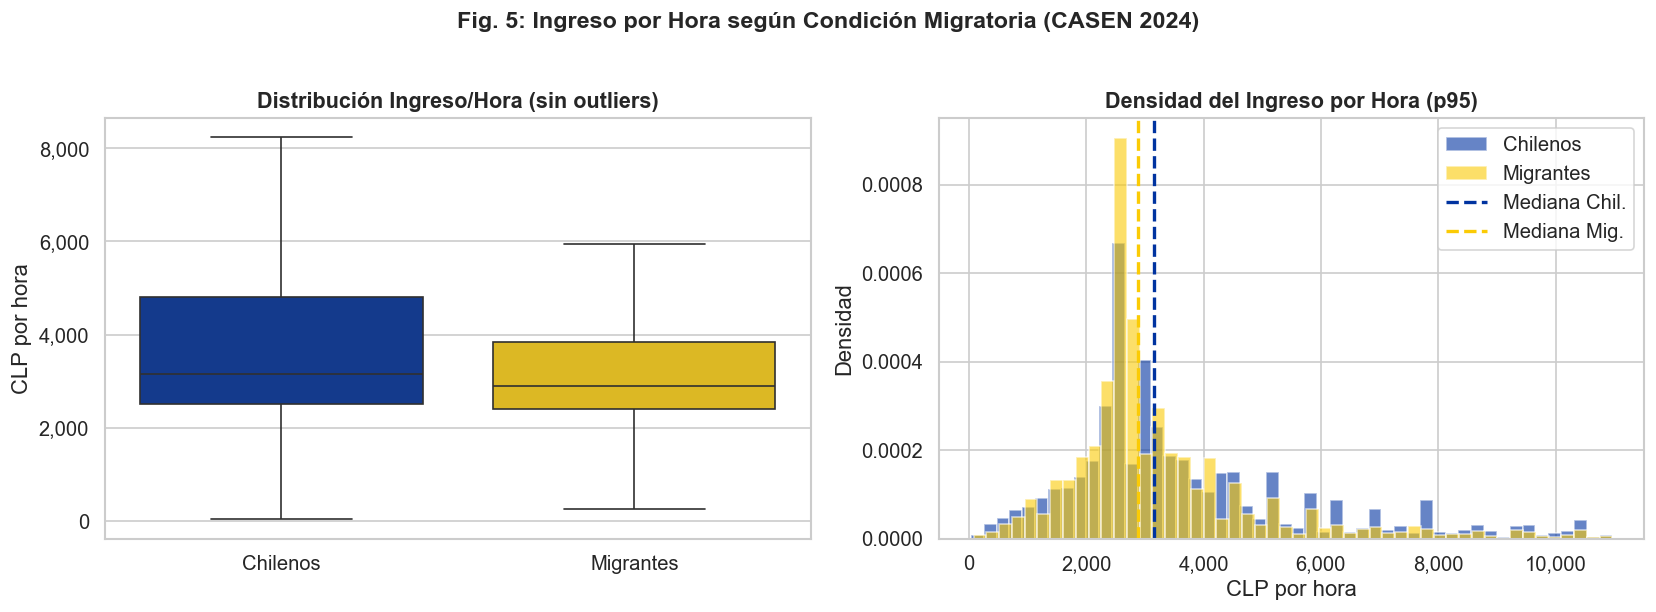

In [9]:
# Figura 5: Distribución de ingreso por hora (boxplot + histograma)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=cas_ocup, x='grupo', y='ingreso_hora',
            palette=COLORES, ax=axes[0], showfliers=False,
            order=['Chilenos', 'Migrantes'])
axes[0].set_title("Distribución Ingreso/Hora (sin outliers)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("CLP por hora")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Histograma superpuesto
lim = cas_ocup['ingreso_hora'].quantile(0.95)
for grupo, color in COLORES.items():
    subset = cas_ocup[cas_ocup['grupo'] == grupo]['ingreso_hora']
    axes[1].hist(subset[subset <= lim], bins=50, alpha=0.6,
                 color=color, label=grupo, density=True)
axes[1].axvline(cas_ocup[cas_ocup['grupo']=='Chilenos']['ingreso_hora'].median(),
                color=COLORES['Chilenos'], linestyle='--', linewidth=2, label='Mediana Chil.')
axes[1].axvline(cas_ocup[cas_ocup['grupo']=='Migrantes']['ingreso_hora'].median(),
                color=COLORES['Migrantes'], linestyle='--', linewidth=2, label='Mediana Mig.')
axes[1].set_title("Densidad del Ingreso por Hora (p95)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("CLP por hora")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle("Fig. 5: Ingreso por Hora según Condición Migratoria (CASEN 2024)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig05_ingreso_hora.png'))
plt.show()

## 5. Distribución ocupacional y sectorial

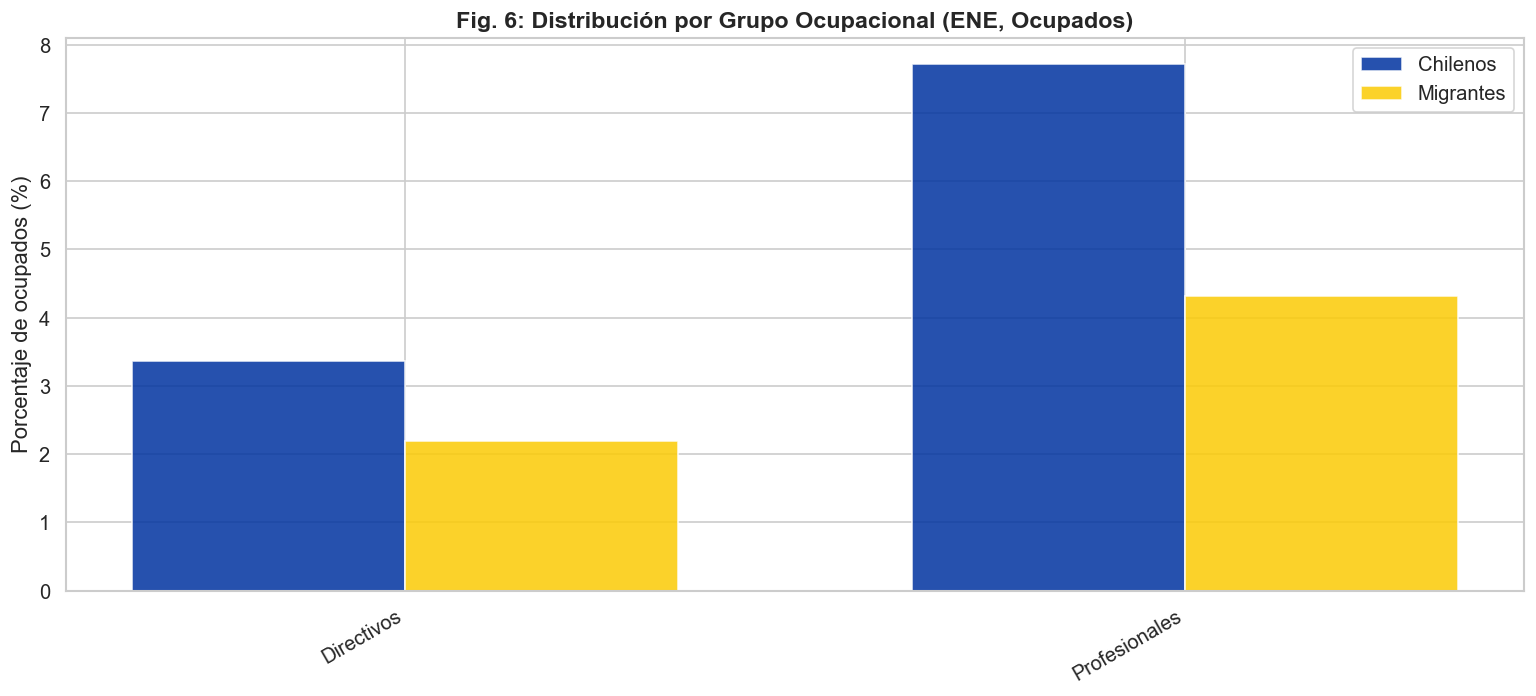

In [10]:
# Figura 6: Distribución por grupo ocupacional
fig, ax = plt.subplots(figsize=(13, 6))

ocup_data = ene[ene['activ']==1].groupby(['grupo','ocup_grupo']).size().unstack(fill_value=0)
ocup_pct  = ocup_data.div(ocup_data.sum(axis=1), axis=0) * 100
ocup_order = ['Directivos','Profesionales','Tecnicos','Admin','Servicios','Agro','Artesanos','Elementales']
ocup_plot = ocup_pct.reindex(columns=[c for c in ocup_order if c in ocup_pct.columns])

x = np.arange(len(ocup_plot.columns))
width = 0.35
for i, (grupo, row) in enumerate(ocup_plot.iterrows()):
    ax.bar(x + i*width - width/2, row.values, width=width,
           label=grupo, color=list(COLORES.values())[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(ocup_plot.columns, rotation=30, ha='right')
ax.set_ylabel("Porcentaje de ocupados (%)")
ax.set_title("Fig. 6: Distribución por Grupo Ocupacional (ENE, Ocupados)", fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig06_grupos_ocupacionales.png'))
plt.show()

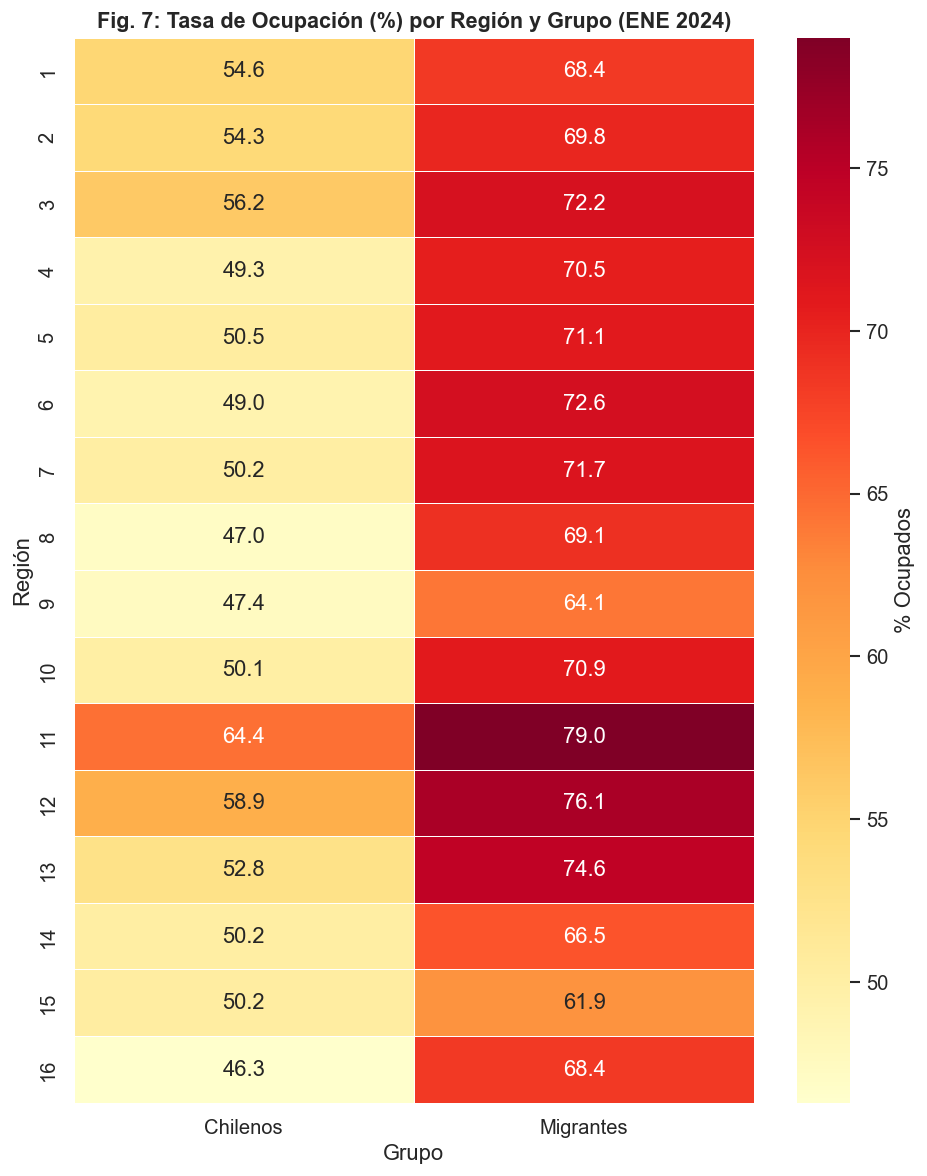

In [11]:
# Figura 7: Heatmap región × condición migratoria (tasa de ocupación)
fig, ax = plt.subplots(figsize=(8, 10))

hm_data = ene.groupby(['region','grupo'])['ocupado'].mean().unstack() * 100
sns.heatmap(hm_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% Ocupados'})
ax.set_title("Fig. 7: Tasa de Ocupación (%) por Región y Grupo (ENE 2024)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Grupo")
ax.set_ylabel("Región")
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig07_heatmap_region_grupo.png'))
plt.show()

## 6. Análisis del Índice de Inserción Laboral Multidimensional (IILM)

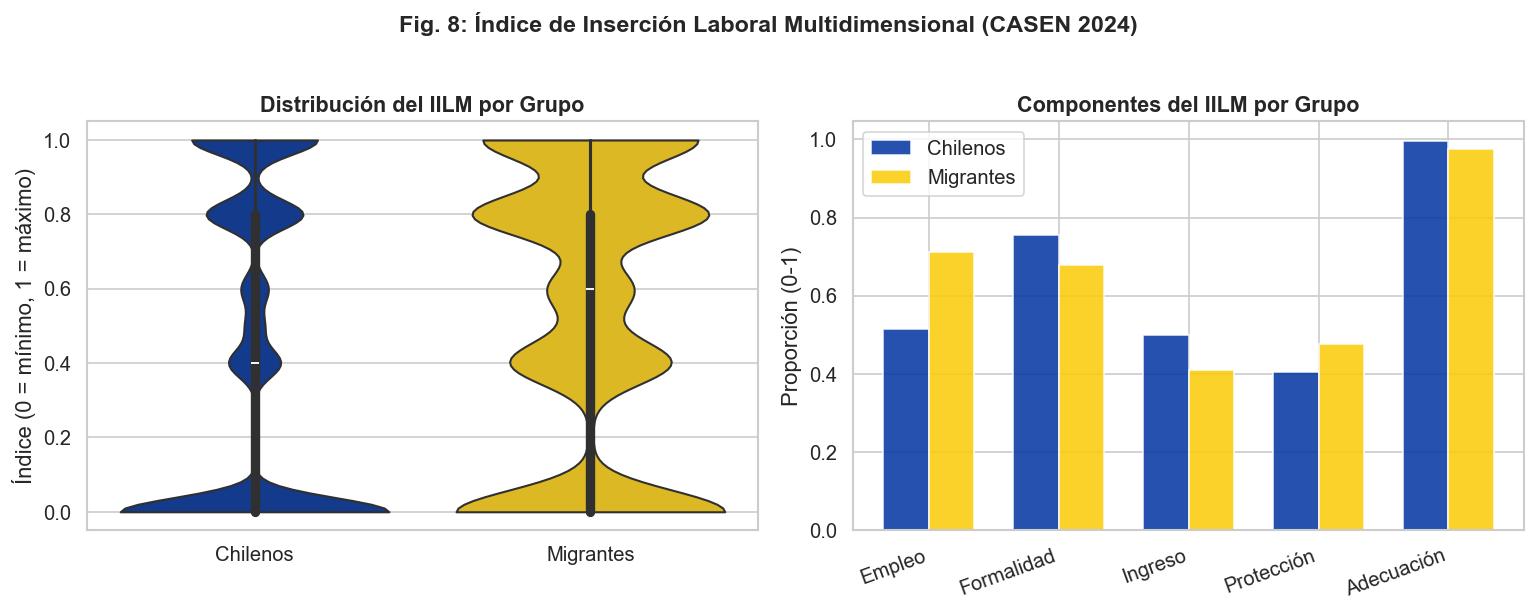

In [12]:
# Figura 8: IILM por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violinplot
cas_15 = cas[cas['iilm'].notna()].copy()
sns.violinplot(data=cas_15, x='grupo', y='iilm',
               palette=COLORES, ax=axes[0], inner='box', cut=0)
axes[0].set_title("Distribución del IILM por Grupo", fontsize=13, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Índice (0 = mínimo, 1 = máximo)")

# Componentes del IILM por grupo
dims = ['dim_empleo','dim_formalidad','dim_ingreso','dim_proteccion','dim_adecuacion']
dims_labels = ['Empleo','Formalidad','Ingreso','Protección','Adecuación']
iilm_comp = cas_15.groupby('grupo')[dims].mean()
x = np.arange(len(dims))
width = 0.35
for i, (grupo, row) in enumerate(iilm_comp.iterrows()):
    axes[1].bar(x + i*width - width/2, row.values, width=width,
                label=grupo, color=list(COLORES.values())[i], alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(dims_labels, rotation=20, ha='right')
axes[1].set_ylabel("Proporción (0-1)")
axes[1].set_title("Componentes del IILM por Grupo", fontsize=13, fontweight='bold')
axes[1].legend()

fig.suptitle("Fig. 8: Índice de Inserción Laboral Multidimensional (CASEN 2024)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig08_iilm_componentes.png'))
plt.show()

## 7. Distribución de ingresos: histograma de Pareto con curvas acumuladas

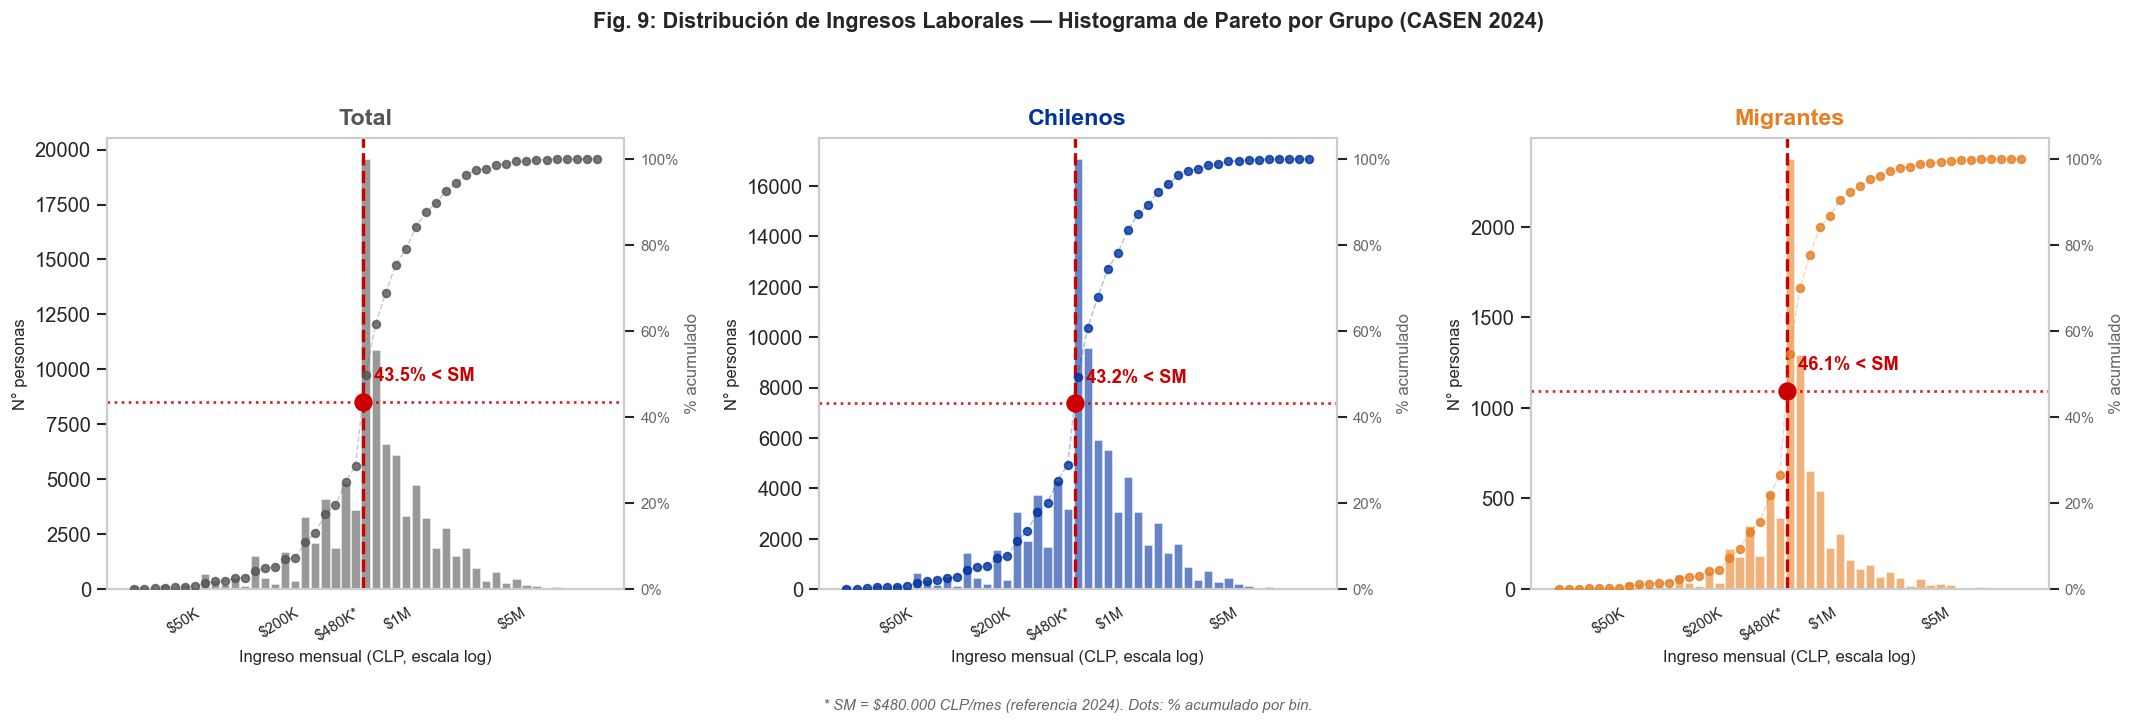

In [13]:
# Figura 9: Histograma de Pareto — 3 paneles separados (Total / Chilenos / Migrantes)
# Eje izq: N° personas por bin  |  Eje der: % acumulado (dots por bin)
# Línea vertical roja (--) = SM $480K | Línea horizontal roja (...) = % que gana < SM
SM = 480000
log_sm = np.log10(SM)

cas_ing = cas[(cas['activ'] == 1) & (cas['ingreso_trabajo'].notna()) & (cas['ingreso_trabajo'] > 0)].copy()
cas_ing['log_ing'] = np.log10(cas_ing['ingreso_trabajo'])

bins = np.linspace(4.25, 7.15, 48)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_w = bins[1] - bins[0]

grupos_cfg = [
    ('Total',     cas_ing['log_ing'],                                   '#555555'),
    ('Chilenos',  cas_ing[cas_ing['grupo'] == 'Chilenos']['log_ing'],   '#0033A0'),
    ('Migrantes', cas_ing[cas_ing['grupo'] == 'Migrantes']['log_ing'],  '#e67e22'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')

xticks_vals = [50000, 200000, 480000, 1000000, 5000000]
xlabels_str  = ['$50K', '$200K', '$480K*', '$1M', '$5M']

for ax1, (grupo, data, color) in zip(axes, grupos_cfg):
    ax2 = ax1.twinx()
    ax1.set_facecolor('white')
    ax1.grid(False)
    ax2.grid(False)

    # Histograma (conteos reales)
    counts, _ = np.histogram(data, bins=bins)
    ax1.bar(bin_centers, counts, width=bin_w * 0.82,
            color=color, alpha=0.60, edgecolor='white', linewidth=0.4)

    # Acumulada: dots por bin + línea tenue de conexión
    cum_pct = np.cumsum(counts) / counts.sum() * 100
    ax2.plot(bin_centers, cum_pct, color=color, linewidth=0.9, linestyle='--', alpha=0.30)
    ax2.scatter(bin_centers, cum_pct, color=color, s=22, zorder=5, alpha=0.80)

    # Línea vertical SM
    ax1.axvline(log_sm, color='#cc0000', linestyle='--', linewidth=2.0, zorder=3)

    # % del grupo que gana menos que SM y línea horizontal
    pct_at_sm = float(np.interp(log_sm, bin_centers, cum_pct))  # interseccion exacta sobre la curva
    ax2.axhline(pct_at_sm, color='#cc0000', linestyle=':', linewidth=1.6, alpha=0.85)

    # Punto rojo en la intersección
    ax2.scatter([log_sm], [pct_at_sm], color='#cc0000', s=100, zorder=6)

    # Anotación del % dentro del panel
    offset_y = 4 if pct_at_sm < 85 else -9
    ax2.text(log_sm + 0.07, pct_at_sm + offset_y,
             f'{pct_at_sm:.1f}% < SM',
             color='#cc0000', fontsize=11, fontweight='bold', va='bottom')

    # Eje X
    ax1.set_xticks([np.log10(v) for v in xticks_vals])
    ax1.set_xticklabels(xlabels_str, fontsize=9, rotation=32, ha='right')
    ax1.set_xlabel("Ingreso mensual (CLP, escala log)", fontsize=10)
    ax1.set_ylabel("N° personas", fontsize=10)

    # Eje Y derecho (siempre 0-100%)
    ax2.set_ylim(0, 105)
    ax2.set_yticks([0, 20, 40, 60, 80, 100])
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax2.tick_params(labelsize=9, labelcolor='#666666')
    ax2.set_ylabel("% acumulado", fontsize=10, color='#666666')

    ax1.set_title(grupo, fontsize=14, fontweight='bold', color=color, pad=8)

fig.text(0.5, 0.01,
         '* SM = $480.000 CLP/mes (referencia 2024). Dots: % acumulado por bin.',
         ha='center', fontsize=9, color='#666666', style='italic')
fig.suptitle("Fig. 9: Distribución de Ingresos Laborales — Histograma de Pareto por Grupo (CASEN 2024)",
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.94])
plt.savefig(os.path.join(FIG, 'fig09_pareto_ingresos.png'), dpi=130, bbox_inches='tight')
plt.show()

## 8. Distribución por tramos de ingreso relativo al sueldo mínimo

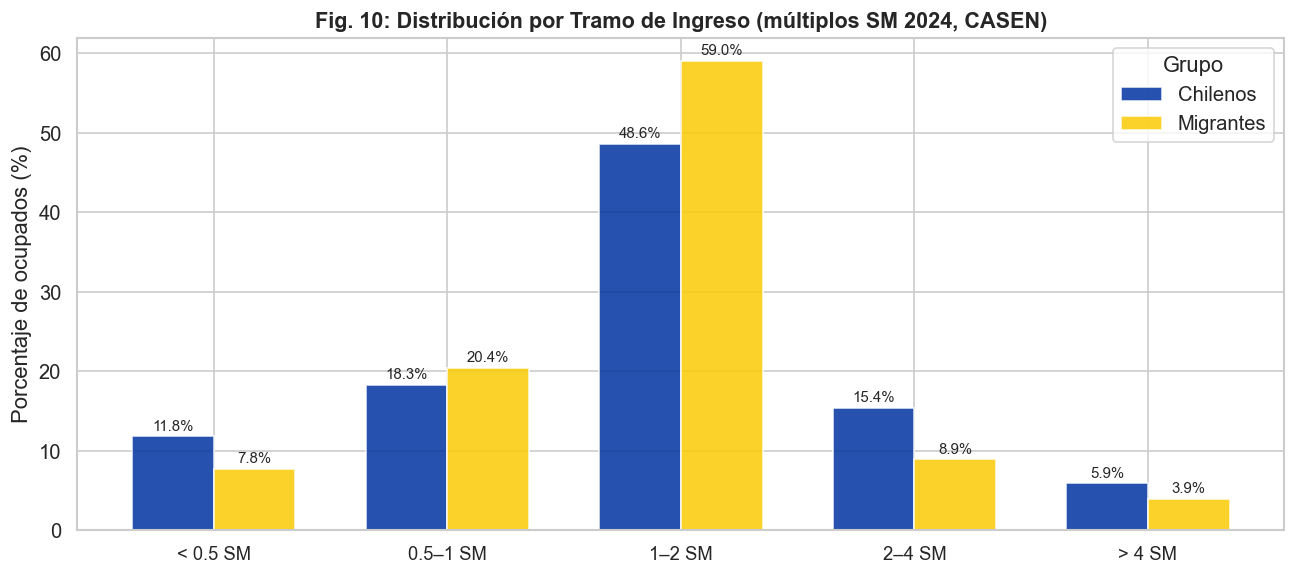

Tabla por tramo de ingreso:
tramo      < 0.5 SM  0.5–1 SM  1–2 SM  2–4 SM  > 4 SM
grupo                                                
Chilenos       11.8      18.3    48.6    15.4     5.9
Migrantes       7.8      20.4    59.0     8.9     3.9


In [14]:
# Figura 10: Porcentaje por tramo de ingreso (múltiplos del sueldo mínimo 2024)
SM2024 = 480000  # sueldo mínimo referencia 2024

cas_ing['tramo'] = pd.cut(
    cas_ing['ingreso_trabajo'],
    bins=[0, SM2024 * 0.5, SM2024, SM2024 * 2, SM2024 * 4, np.inf],
    labels=['< 0.5 SM', '0.5–1 SM', '1–2 SM', '2–4 SM', '> 4 SM']
)

tramo_grupo = (cas_ing.groupby(['grupo', 'tramo'], observed=True)
               .size().unstack(fill_value=0))
tramo_pct = tramo_grupo.div(tramo_grupo.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(tramo_pct.columns))
width = 0.35
for i, (grupo, row) in enumerate(tramo_pct.iterrows()):
    bars = ax.bar(x + i * width - width / 2, row.values, width=width,
                  label=grupo, color=list(COLORES.values())[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        if bar.get_height() > 2:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                    f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(tramo_pct.columns, fontsize=11)
ax.set_ylabel("Porcentaje de ocupados (%)")
ax.set_title("Fig. 10: Distribución por Tramo de Ingreso (múltiplos SM 2024, CASEN)",
             fontsize=13, fontweight='bold')
ax.legend(title='Grupo')
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig10_tramos_ingreso.png'))
plt.show()

print("Tabla por tramo de ingreso:")
print(tramo_pct.round(1).to_string())

## 9. Correlación de Spearman entre variables clave

**¿Por qué Spearman y no Pearson?**

La correlación de Spearman es más adecuada en este análisis porque:
1. **Variables ordinales y binarias:** `migrante`, `formal`, `cotiza` son binarias; `educa` es una escala ordinal de 7 niveles. Pearson asume escala de intervalo con distancias iguales entre categorías, supuesto que no se cumple aquí.
2. **Ingresos sesgados:** `ingreso_hora` tiene una distribución fuertemente asimétrica a la derecha incluso tras la winsorización al p99 (típico de datos de ingresos). Pearson es sensible a colas pesadas y outliers.
3. **Sin supuesto de normalidad:** Spearman trabaja con rangos, siendo robusto para cualquier distribución marginal.

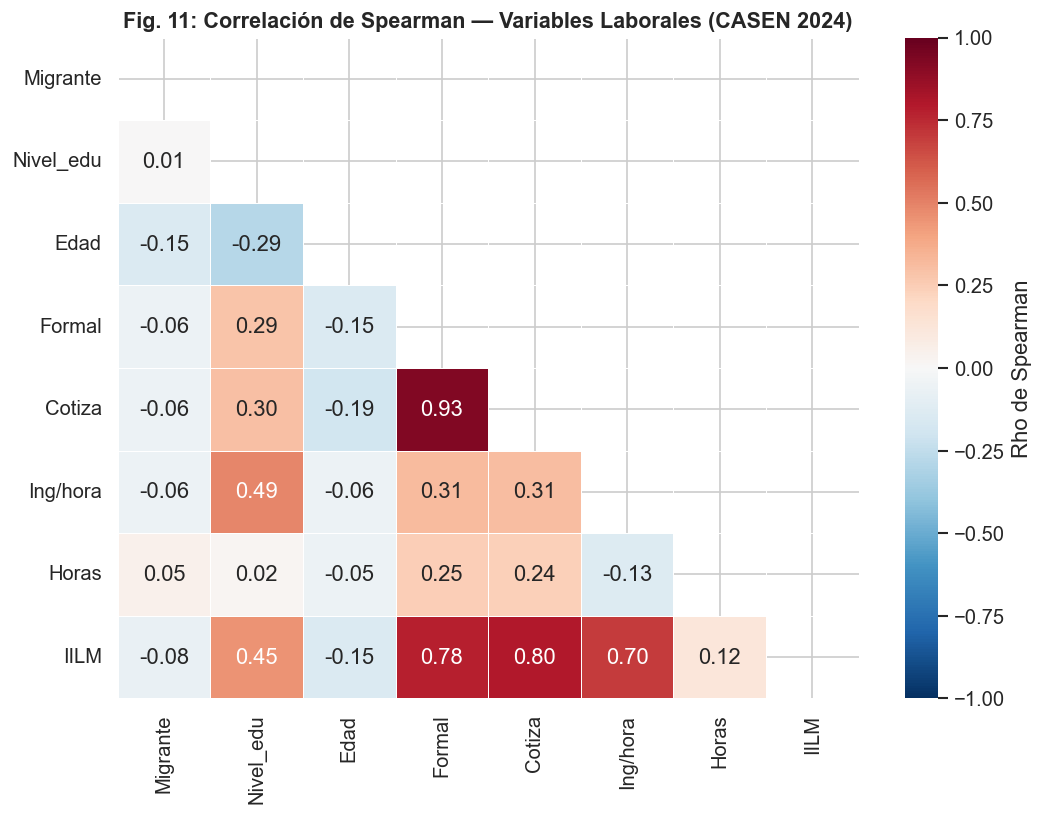

Correlaciones con 'Migrante':
Edad        -0.145403
IILM        -0.078025
Ing/hora    -0.058826
Formal      -0.056318
Cotiza      -0.055485
Nivel_edu    0.006409
Horas        0.048295
Migrante     1.000000


In [15]:
# Figura 11: Mapa de calor — correlación de Spearman (variables laborales y migrante)
from scipy.stats import spearmanr

cas_corr = cas[(cas['activ'] == 1) & (cas['migrante'].notna())].copy()
corr_vars = ['migrante', 'educa', 'edad', 'formal', 'cotiza',
             'ingreso_hora', 'horas_semana', 'iilm']
corr_vars = [v for v in corr_vars if v in cas_corr.columns]

corr_data = cas_corr[corr_vars].dropna()
corr_matrix = corr_data.corr(method='spearman')

labels_map = {
    'migrante': 'Migrante', 'educa': 'Nivel_edu', 'edad': 'Edad',
    'formal': 'Formal', 'cotiza': 'Cotiza', 'ingreso_hora': 'Ing/hora',
    'horas_semana': 'Horas', 'iilm': 'IILM'
}
corr_matrix.index = [labels_map.get(c, c) for c in corr_matrix.index]
corr_matrix.columns = [labels_map.get(c, c) for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Rho de Spearman'})
ax.set_title("Fig. 11: Correlación de Spearman — Variables Laborales (CASEN 2024)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig11_correlacion_spearman.png'))
plt.show()

print("Correlaciones con 'Migrante':")
print(corr_matrix['Migrante'].sort_values().to_string())

## 10. Prueba de diferencia de medias (Welch t-test) e intervalo de confianza

**¿Por qué Welch t-test y no t-test estándar?**

El test de Welch no asume varianzas iguales entre grupos (a diferencia del t-test de Student clásico). Dado que los ingresos de Chilenos y Migrantes tienen distribuciones con varianzas distintas (mayor dispersión en Chilenos por su mayor proporción en sectores de altos ingresos), el test de Welch es el más apropiado.

**¿Qué muestra el panel derecho?**

El bootstrap de 5.000 iteraciones estima la distribución de la *diferencia de medias* (Chilenos − Migrantes) en CLP/hora. Un rango de 0–1.000 CLP/h para esta diferencia es correcto: equivale a ~87.000–173.000 CLP/mes de brecha (×87–173 horas), que es el diferencial salarial esperado entre grupos controlando por la winsorización al p99.

=== PRUEBA WELCH t-TEST: INGRESO/HORA CHILENOS vs MIGRANTES ===
n Chilenos:  82,405  |  mediana: 3,149 CLP/h
n Migrantes: 8,321  |  mediana: 2,887 CLP/h
Diferencia de medias: 577 CLP/h
t-statistic: 17.4548  |  p-value: 2.649041e-67
Bootstrap IC 95% (diferencia de medias): [389, 772] CLP/h
Conclusión: diferencia estadisticamente significativa al 5%


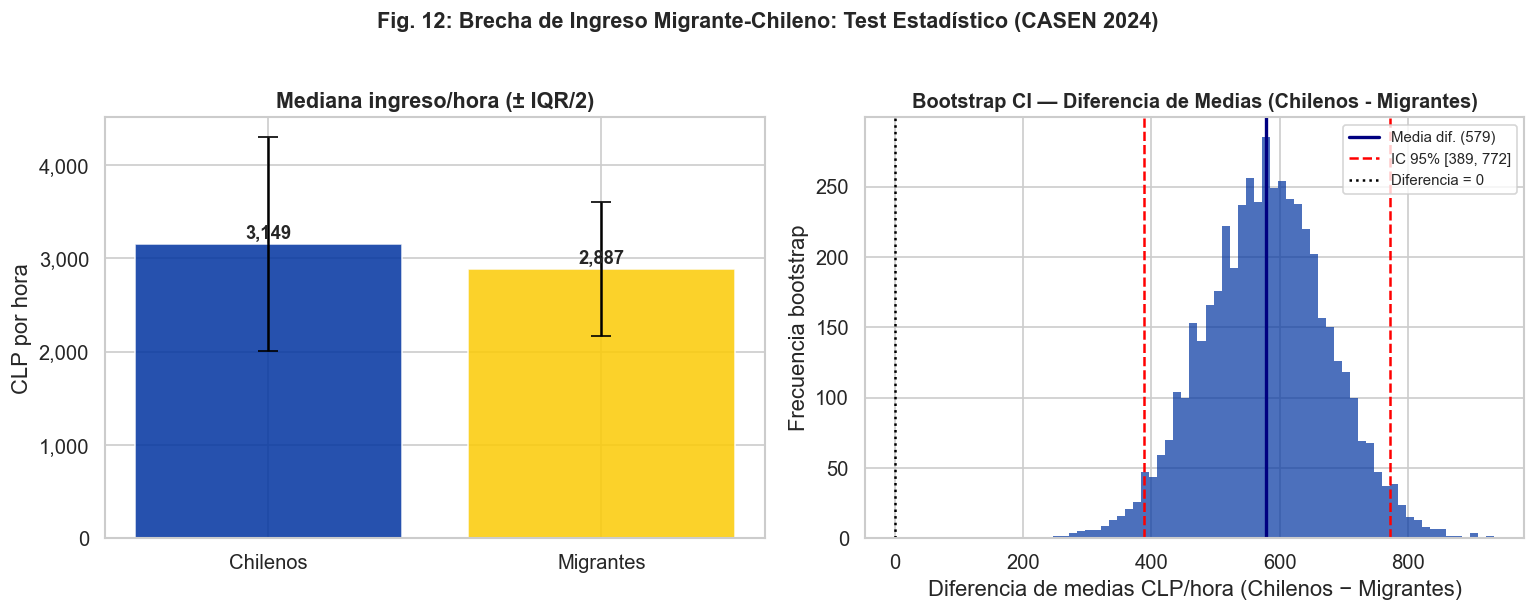

In [16]:
# Figura 12: T-test Welch + intervalo de confianza para brecha de ingreso
from scipy import stats

ing_chil = cas[(cas['migrante'] == 0) & (cas['activ'] == 1) & (cas['ingreso_hora'].notna())]['ingreso_hora']
ing_migr = cas[(cas['migrante'] == 1) & (cas['activ'] == 1) & (cas['ingreso_hora'].notna())]['ingreso_hora']

t_stat, p_val = stats.ttest_ind(ing_chil, ing_migr, equal_var=False)
diff_median = ing_chil.median() - ing_migr.median()
diff_mean   = ing_chil.mean()   - ing_migr.mean()

# Bootstrap CI para diferencia de medianas
np.random.seed(42)
n_boot = 5000
boot_diff = [
    np.random.choice(ing_chil, size=min(2000, len(ing_chil)), replace=True).mean() -
    np.random.choice(ing_migr, size=min(2000, len(ing_migr)), replace=True).mean()
    for _ in range(n_boot)
]
ci_low, ci_high = np.percentile(boot_diff, [2.5, 97.5])

print("=== PRUEBA WELCH t-TEST: INGRESO/HORA CHILENOS vs MIGRANTES ===")
print(f"n Chilenos:  {len(ing_chil):,}  |  mediana: {ing_chil.median():,.0f} CLP/h")
print(f"n Migrantes: {len(ing_migr):,}  |  mediana: {ing_migr.median():,.0f} CLP/h")
print(f"Diferencia de medias: {diff_mean:,.0f} CLP/h")
print(f"t-statistic: {t_stat:.4f}  |  p-value: {p_val:.6e}")
print(f"Bootstrap IC 95% (diferencia de medias): [{ci_low:,.0f}, {ci_high:,.0f}] CLP/h")
print(f"Conclusión: {'diferencia estadisticamente significativa' if p_val < 0.05 else 'no significativa'} al 5%")

# Figura
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izq: mediana con error bootstrap
medianas  = [ing_chil.median(), ing_migr.median()]
errores   = [(ing_chil.quantile(0.75) - ing_chil.quantile(0.25)) / 2,
             (ing_migr.quantile(0.75) - ing_migr.quantile(0.25)) / 2]
bars = axes[0].bar(['Chilenos', 'Migrantes'], medianas,
                   color=list(COLORES.values()), yerr=errores,
                   capsize=6, edgecolor='white', alpha=0.85)
axes[0].set_title("Mediana ingreso/hora (± IQR/2)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("CLP por hora")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, medianas):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                 f'{val:,.0f}', ha='center', fontsize=11, fontweight='bold')

# Panel der: distribución bootstrap de diferencia de medias
axes[1].hist(boot_diff, bins=60, color='#0033A0', alpha=0.7, edgecolor='none')
axes[1].axvline(np.mean(boot_diff), color='navy', linewidth=2, label=f'Media dif. ({np.mean(boot_diff):,.0f})')
axes[1].axvline(ci_low, color='red', linestyle='--', linewidth=1.5, label=f'IC 95% [{ci_low:,.0f}, {ci_high:,.0f}]')
axes[1].axvline(ci_high, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(0, color='black', linestyle=':', linewidth=1.5, label='Diferencia = 0')
axes[1].set_title("Bootstrap CI — Diferencia de Medias (Chilenos - Migrantes)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Diferencia de medias CLP/hora (Chilenos − Migrantes)")
axes[1].set_ylabel("Frecuencia bootstrap")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle("Fig. 12: Brecha de Ingreso Migrante-Chileno: Test Estadístico (CASEN 2024)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig12_ttest_brecha_ingreso.png'))
plt.show()

## 11. Síntesis

In [17]:
# Tabla síntesis de resultados EDA
print("=== SÍNTESIS DESCRIPTIVA POR CONDICIÓN MIGRATORIA ===")
print()

# ENE
ene_resumen = pd.DataFrame({
    'Indicador': [
        'N en muestra ENE',
        'Tasa de ocupación (%)',
        'Tasa de desocupación (%)',
        'Tasa de formalidad (ocupados, %)',
        'Horas habituales (mediana)',
        '% en ocupaciones elementales',
        '% con educación superior',
    ],
    'Chilenos': [
        f"{(ene['grupo']=='Chilenos').sum():,}",
        f"{ene[ene['grupo']=='Chilenos']['ocupado'].mean()*100:.1f}%",
        f"{ene[ene['grupo']=='Chilenos']['desocupado'].mean()*100:.1f}%",
        f"{ene[(ene['grupo']=='Chilenos') & (ene['activ']==1)]['formal'].mean()*100:.1f}%",
        f"{ene[ene['grupo']=='Chilenos']['horas_habituales'].median():.0f} h",
        f"{ene[(ene['grupo']=='Chilenos')&(ene['activ']==1)]['ocup_grupo'].eq('Elementales').mean()*100:.1f}%",
        f"{ene[ene['grupo']=='Chilenos']['cine11_1d'].isin([4,5,6]).mean()*100:.1f}%",
    ],
    'Migrantes': [
        f"{(ene['grupo']=='Migrantes').sum():,}",
        f"{ene[ene['grupo']=='Migrantes']['ocupado'].mean()*100:.1f}%",
        f"{ene[ene['grupo']=='Migrantes']['desocupado'].mean()*100:.1f}%",
        f"{ene[(ene['grupo']=='Migrantes') & (ene['activ']==1)]['formal'].mean()*100:.1f}%",
        f"{ene[ene['grupo']=='Migrantes']['horas_habituales'].median():.0f} h",
        f"{ene[(ene['grupo']=='Migrantes')&(ene['activ']==1)]['ocup_grupo'].eq('Elementales').mean()*100:.1f}%",
        f"{ene[ene['grupo']=='Migrantes']['cine11_1d'].isin([4,5,6]).mean()*100:.1f}%",
    ]
})
print(ene_resumen.to_string(index=False))
print()

# CASEN
print("CASEN - Ingreso y bienestar:")
cas_resumen = cas[cas['migrante'].notna()].groupby('grupo').agg(
    ing_hora_mediana=('ingreso_hora', 'median'),
    pct_pobres=('en_pobreza', 'mean'),
    pct_pobreza_multi=('pobreza_multi_bn','mean'),
    iilm_medio=('iilm','mean')
).round(3)
print(cas_resumen.to_string())

=== SÍNTESIS DESCRIPTIVA POR CONDICIÓN MIGRATORIA ===



                       Indicador Chilenos Migrantes
                N en muestra ENE  310,798    14,390
           Tasa de ocupación (%)    50.8%     71.5%
        Tasa de desocupación (%)     4.6%      5.5%
Tasa de formalidad (ocupados, %)    69.8%     63.7%
      Horas habituales (mediana)     44 h      45 h
    % en ocupaciones elementales     0.0%      0.0%
        % con educación superior    14.2%     19.8%

CASEN - Ingreso y bienestar:
           ing_hora_mediana  pct_pobres  pct_pobreza_multi  iilm_medio
grupo                                                                 
Chilenos           3149.276       0.174              0.157       0.424
Migrantes          2886.836       0.258              0.284       0.536


## 12. Distribución educativa desde CASEN (variable `educa` reconstruida)

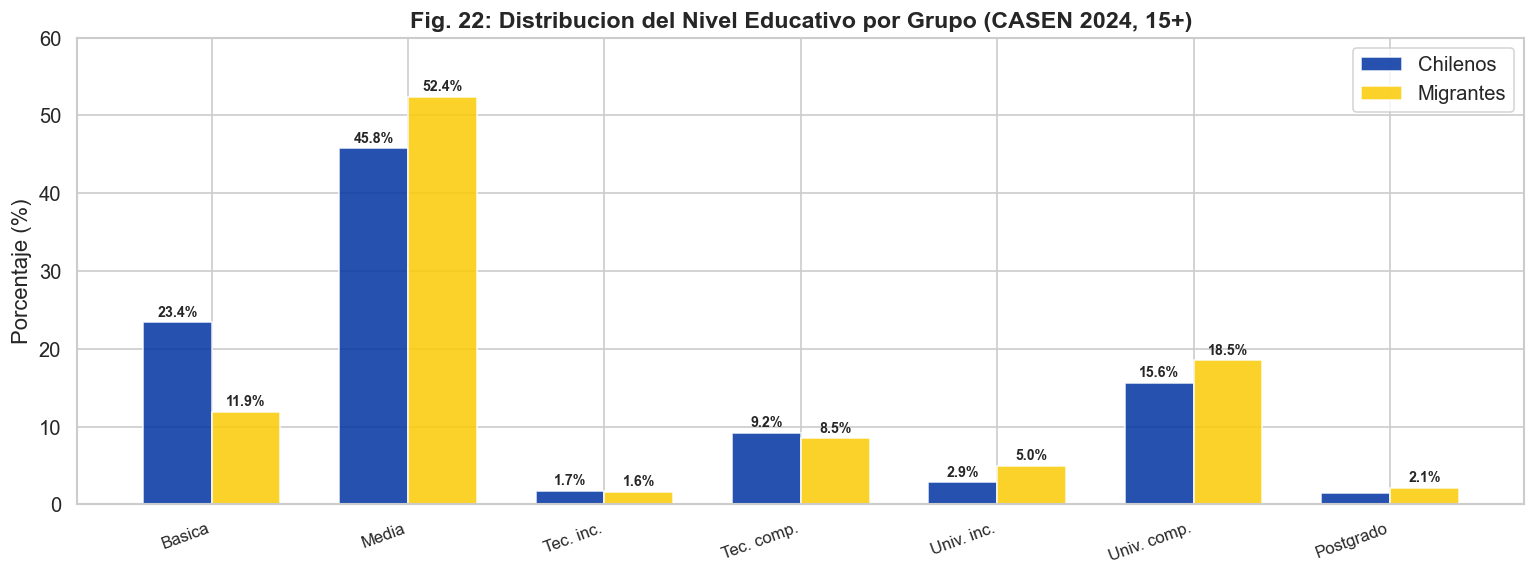

Tabla:
edu_label  Basica  Media  Tec. inc.  Tec. comp.  Univ. inc.  Univ. comp.  Postgrado
grupo                                                                              
Chilenos     23.4   45.8        1.7         9.2         2.9         15.6        1.4
Migrantes    11.9   52.4        1.6         8.5         5.0         18.5        2.1


In [18]:
# Figura 22: Distribucion educativa CASEN 7 niveles (Basica -> Postgrado)
# Universo: todos los 15+ con educa disponible
# Fuente: casen_procesada.parquet  variable 'educa' reconstruida en notebook 02

edu_labels = {1: 'Basica', 2: 'Media', 3: 'Tec. inc.', 4: 'Tec. comp.',
              5: 'Univ. inc.', 6: 'Univ. comp.', 7: 'Postgrado'}
edu_order_cas = ['Basica', 'Media', 'Tec. inc.', 'Tec. comp.',
                 'Univ. inc.', 'Univ. comp.', 'Postgrado']

cas_edu = cas[cas['educa'].notna()].copy()
cas_edu['edu_label'] = cas_edu['educa'].map(edu_labels)

edu_dist = (cas_edu.groupby(['grupo', 'edu_label'])
            .size().unstack(fill_value=0))
edu_pct  = edu_dist.div(edu_dist.sum(axis=1), axis=0) * 100
edu_pct  = edu_pct.reindex(columns=[c for c in edu_order_cas if c in edu_pct.columns])

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(edu_pct.columns))
width = 0.35
for i, (grupo, row) in enumerate(edu_pct.iterrows()):
    bars = ax.bar(x + i*width - width/2, row.values, width=width,
                  label=grupo, color=list(COLORES.values())[i],
                  alpha=0.85, edgecolor='white')
    for bar in bars:
        if bar.get_height() >= 1.5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                    f'{bar.get_height():.1f}%',
                    ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(edu_pct.columns, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Porcentaje (%)')
ax.set_ylim(0, 60)
ax.set_title('Fig. 22: Distribucion del Nivel Educativo por Grupo (CASEN 2024, 15+)',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig22_edu_casen.png'))
plt.show()

print('Tabla:')
print(edu_pct.round(1).to_string())


## 13. Grupos ocupacionales CIUO-08 (CASEN, ocupados)

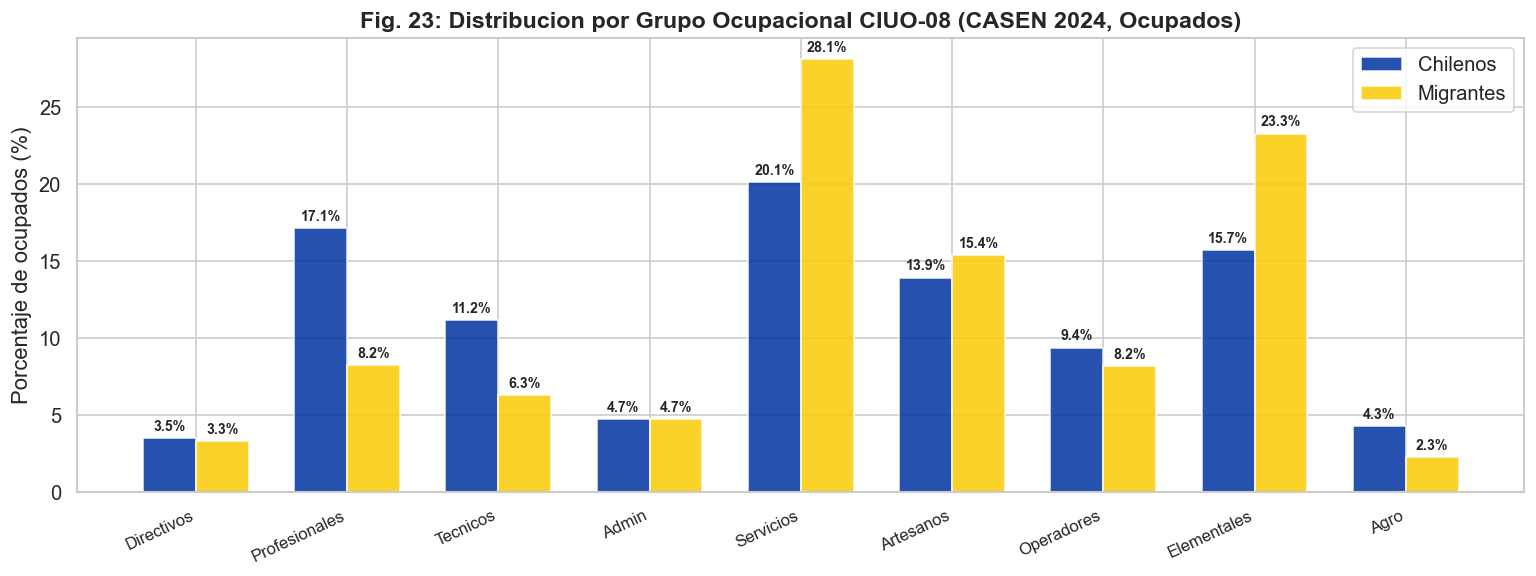

Tabla CIUO:
ocup_grupo  Directivos  Profesionales  Tecnicos  Admin  Servicios  Artesanos  Operadores  Elementales  Agro
grupo                                                                                                      
Chilenos           3.5           17.1      11.2    4.7       20.1       13.9         9.4         15.7   4.3
Migrantes          3.3            8.2       6.3    4.7       28.1       15.4         8.2         23.3   2.3


In [19]:
# Figura 23: Distribucion por grupo ocupacional CIUO-08 desde CASEN (solo ocupados)
# Revela la brecha Profesionales vs Elementales entre Chilenos y Migrantes

ciuo_order = ['Directivos', 'Profesionales', 'Tecnicos', 'Admin',
              'Servicios', 'Artesanos', 'Operadores', 'Elementales', 'Agro']

cas_ocup = cas[cas['activ'] == 1].copy()
ciuo_dist = (cas_ocup.groupby(['grupo', 'ocup_grupo'])
             .size().unstack(fill_value=0))
ciuo_pct = ciuo_dist.div(ciuo_dist.sum(axis=1), axis=0) * 100
ciuo_pct = ciuo_pct.reindex(columns=[c for c in ciuo_order if c in ciuo_pct.columns])

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(ciuo_pct.columns))
width = 0.35
for i, (grupo, row) in enumerate(ciuo_pct.iterrows()):
    bars = ax.bar(x + i*width - width/2, row.values, width=width,
                  label=grupo, color=list(COLORES.values())[i],
                  alpha=0.85, edgecolor='white')
    for bar in bars:
        if bar.get_height() >= 1.5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{bar.get_height():.1f}%',
                    ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(ciuo_pct.columns, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Porcentaje de ocupados (%)')
ax.set_title('Fig. 23: Distribucion por Grupo Ocupacional CIUO-08 (CASEN 2024, Ocupados)',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig23_ciuo_casen.png'))
plt.show()

print('Tabla CIUO:')
print(ciuo_pct.round(1).to_string())


## 14. Distribución sectorial CIIU — Rama económica (CASEN, ocupados)

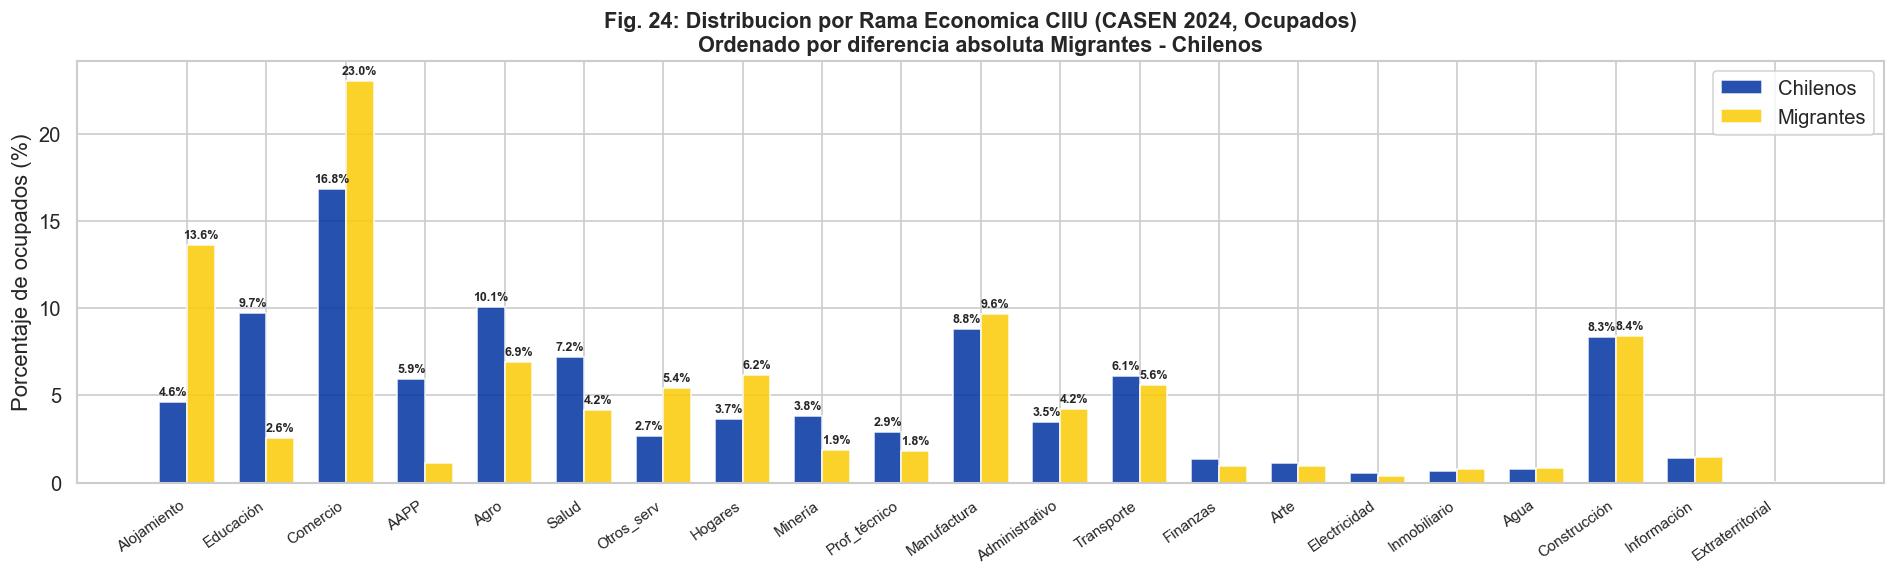

Tabla CIIU (% por grupo):
rama_eco   Alojamiento  Educación  Comercio  AAPP  Agro  Salud  Otros_serv  Hogares  Minería  Prof_técnico  Manufactura  Administrativo  Transporte  Finanzas  Arte  Electricidad  Inmobiliario  Agua  Construcción  Información  Extraterritorial
grupo                                                                                                                                                                                                                                             
Chilenos           4.6        9.7      16.8   5.9  10.1    7.2         2.7      3.7      3.8           2.9          8.8             3.5         6.1       1.4   1.1           0.5           0.7   0.8           8.3          1.4               0.0
Migrantes         13.6        2.6      23.0   1.2   6.9    4.2         5.4      6.2      1.9           1.8          9.6             4.2         5.6       0.9   0.9           0.4           0.8   0.9           8.4          1.5               0.0

D

In [20]:
# Figura 24: Distribucion por rama economica CIIU (CASEN, solo ocupados)
# Ordenado por diferencia absoluta Migrantes - Chilenos
# Muestra concentracion en alojamiento/domestico y exclusion de sector publico/educacion

rama_dist = (cas_ocup.groupby(['grupo', 'rama_eco'])
             .size().unstack(fill_value=0))
rama_pct = rama_dist.div(rama_dist.sum(axis=1), axis=0) * 100

# Ordenar sectores por diferencia absoluta (los mas discriminantes primero)
if 'Chilenos' in rama_pct.index and 'Migrantes' in rama_pct.index:
    diff_abs = (rama_pct.loc['Migrantes'] - rama_pct.loc['Chilenos']).abs().sort_values(ascending=False)
    rama_order = diff_abs.index.tolist()
else:
    rama_order = rama_pct.columns.tolist()

rama_pct_plot = rama_pct.reindex(columns=[c for c in rama_order if c in rama_pct.columns])

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(rama_pct_plot.columns))
width = 0.35
for i, (grupo, row) in enumerate(rama_pct_plot.iterrows()):
    bars = ax.bar(x + i*width - width/2, row.values, width=width,
                  label=grupo, color=list(COLORES.values())[i],
                  alpha=0.85, edgecolor='white')
    for bar in bars:
        if bar.get_height() >= 1.8:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f'{bar.get_height():.1f}%',
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(rama_pct_plot.columns, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Porcentaje de ocupados (%)')
ax.set_title('Fig. 24: Distribucion por Rama Economica CIIU (CASEN 2024, Ocupados)\n'
             'Ordenado por diferencia absoluta Migrantes - Chilenos',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'fig24_ciiu_casen.png'))
plt.show()

print('Tabla CIIU (% por grupo):')
print(rama_pct_plot.round(1).to_string())

if 'Chilenos' in rama_pct.index and 'Migrantes' in rama_pct.index:
    print('\nDiferencia Migrantes - Chilenos (pp):')
    diff = (rama_pct.loc['Migrantes'] - rama_pct.loc['Chilenos']).sort_values()
    print(diff.round(1).to_string())
